# Cell 1 - Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

plt.style.use("default")

# Database Connection

In [2]:
DB_USER = "postgres"
DB_PASSWORD = "newpassword"
DB_HOST = "localhost"
DB_PORT = "5433"
DB_NAME = "DailyVitals"

connection_string = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

# Load Food Intake Data

In [3]:
query = """
SELECT
    food_phosphorus_intake_id,
    person_id,
    food_name,
    phosphorus_mg,
    calories,
    binders_taken,
    consumed_at,
    serving_description,
    estimated_by_ai
FROM public.food_phosphorus_intake
ORDER BY consumed_at;
"""

food_df = pd.read_sql(query, engine)

food_df["consumed_at"] = pd.to_datetime(
    food_df["consumed_at"]
)

food_df.head()

,food_phosphorus_intake_id,person_id,food_name,phosphorus_mg,calories,binders_taken,consumed_at,serving_description,estimated_by_ai
0,8,4,Apple,25,95,3,2026-05-13,1 apple,False
1,2,4,Small glass of chocolate milk,150,160,3,2026-05-13,NaN,False
2,3,4,Large slice Costco pizza,550,710,3,2026-05-13,NaN,False
3,6,4,pulled pork with BBQ sauce,260,300,3,2026-05-13,3.6 oz,False
4,1,4,Jimmy Bar,182,250,3,2026-05-13,NaN,False


# Daily Nutrition Totals

In [4]:
food_df["date"] = (
    food_df["consumed_at"]
    .dt.date
)

daily_food = (
    food_df
    .groupby("date")
    .agg(
        calories=("calories","sum"),
        phosphorus=("phosphorus_mg","sum"),
        binders=("binders_taken","sum"),
        meals=("food_phosphorus_intake_id","count")
    )
    .reset_index()
)

daily_food.head()

,date,calories,phosphorus,binders,meals
0,2026-05-13,1665,1427,18,6
1,2026-05-14,985,867,12,4
2,2026-05-15,1235,952,18,6
3,2026-05-16,1425,1120,27,9
4,2026-05-17,755,565,7,3


# Daily Calorie Trend

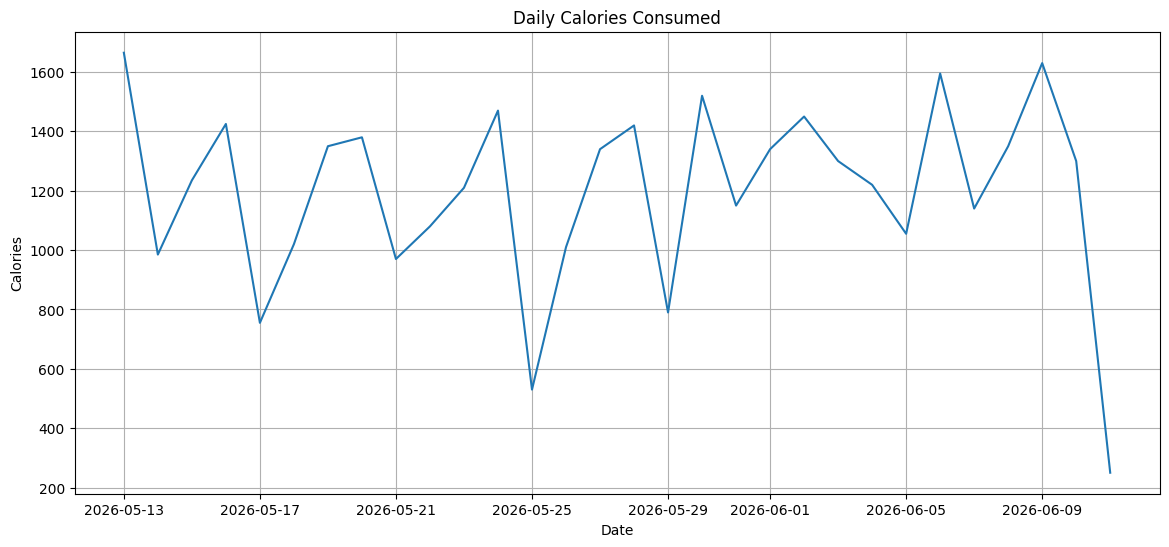

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_food["date"],
    daily_food["calories"]
)

plt.title("Daily Calories Consumed")
plt.ylabel("Calories")
plt.xlabel("Date")

plt.grid(True)

plt.show()

# Daily Phosphorus Trend

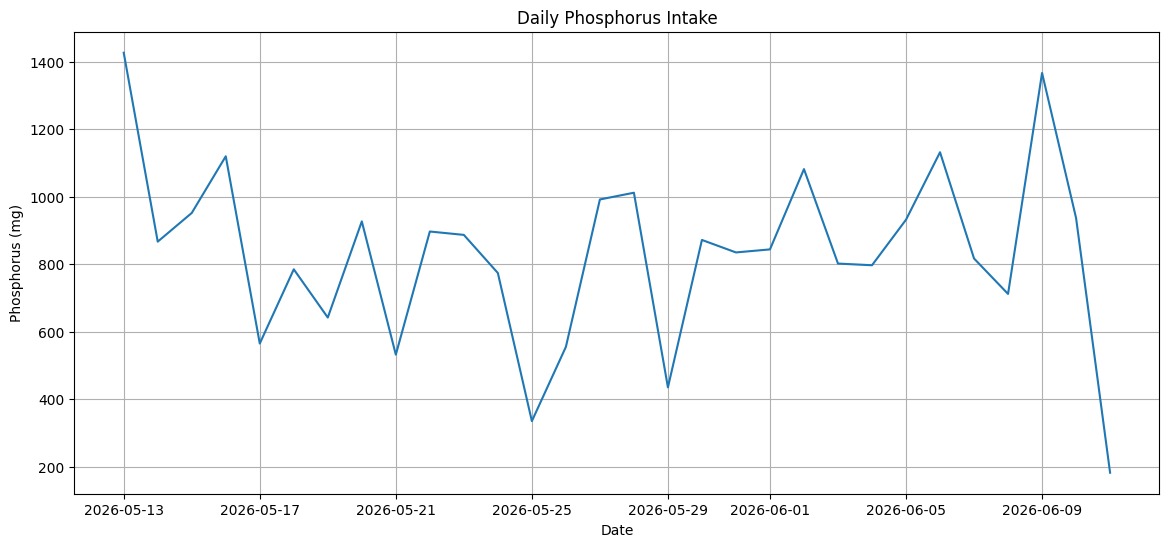

In [6]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_food["date"],
    daily_food["phosphorus"]
)

plt.title("Daily Phosphorus Intake")
plt.ylabel("Phosphorus (mg)")
plt.xlabel("Date")

plt.grid(True)

plt.show()

# Nutrition Statistics

In [7]:
print("Average Daily Calories:")
print(round(daily_food["calories"].mean(),0))

print()

print("Average Daily Phosphorus:")
print(round(daily_food["phosphorus"].mean(),0))

print()

print("Average Meals Logged:")
print(round(daily_food["meals"].mean(),1))

Average Daily Calories:
1198.0

Average Daily Phosphorus:
834.0

Average Meals Logged:
3.4


# Highest Phosphorus Foods

In [8]:
top_phosphorus = (
    food_df
    .groupby("food_name")
    .agg(
        phosphorus=("phosphorus_mg","sum"),
        calories=("calories","sum"),
        times_eaten=("food_name","count")
    )
    .sort_values(
        "phosphorus",
        ascending=False
    )
)

top_phosphorus.head(20)

,phosphorus,calories,times_eaten
food_name,,,
Jimmy Bar,4732,6500,26
homemade grilled cheeseburger (no bun) and a side of 6 tortilla chips,1300,1725,5
Slices of Casey's Pepperoni Pizza (Large pie cuts),1120,1120,2
Large slice Costco pizza,1100,1420,2
English muffin breakfast-for-dinner sandwich with sausage and cheese,870,980,2
beef barbacoa and alfredo noodles,630,690,1
1/4 Pound Cheeseburger and fries,610,880,1
2 single-wrapped Nutty Buddy bars,600,1550,5
"Turkey, Cheese, Ritz crakers (5)",590,520,2


# Phosphorus Density

In [9]:
food_analysis = (
    food_df
    .groupby("food_name")
    .agg(
        phosphorus=("phosphorus_mg","sum"),
        calories=("calories","sum")
    )
)

food_analysis = food_analysis[
    food_analysis["calories"] > 0
]

food_analysis["phosphorus_per_calorie"] = (
    food_analysis["phosphorus"]
    / food_analysis["calories"]
)

food_analysis.sort_values(
    "phosphorus_per_calorie",
    ascending=False
).head(20)

,phosphorus,calories,phosphorus_per_calorie
food_name,,,
baked beans,260,150,1.733333
Pancakes with syrup,285,185,1.540541
Pancakes,270,185,1.459459
1 standard Turkey and Cheddar Lunchables cracker pack,355,260,1.365385
Scrambled Eggs,110,90,1.222222
"Turkey, Cheese, Ritz crakers (5)",590,520,1.134615
4 ounces of Tikka Masala chicken with a minimal teaspoon of white rice,255,235,1.085106
Pork steak,190,185,1.027027
Large Slices of Bacon,120,120,1.000000


# Monthly Nutrition Summary

In [10]:
daily_food["month"] = (
    pd.to_datetime(daily_food["date"])
    .dt.to_period("M")
)

monthly = (
    daily_food
    .groupby("month")
    .agg(
        avg_calories=("calories","mean"),
        avg_phosphorus=("phosphorus","mean"),
        total_calories=("calories","sum")
    )
    .reset_index()
)

monthly

,month,avg_calories,avg_phosphorus,total_calories
0,2026-05,1173.947368,811.105263,22305
1,2026-06,1239.090909,873.090909,13630


# Load Weight Data

In [11]:
weight_query = """
SELECT
    reading_time,
    weight_value
FROM public.weight
ORDER BY reading_time;
"""

weight_df = pd.read_sql(
    weight_query,
    engine
)

weight_df["reading_time"] = pd.to_datetime(
    weight_df["reading_time"]
)

weight_df["date"] = (
    weight_df["reading_time"]
    .dt.date
)

# Merge Nutrition + Weight

In [12]:
combined = pd.merge(
    daily_food,
    weight_df[
        [
            "date",
            "weight_value"
        ]
    ],
    on="date",
    how="inner"
)

combined.head()

,date,calories,phosphorus,binders,meals,month,weight_value
0,2026-05-15,1235,952,18,6,2026-05,207.4
1,2026-05-16,1425,1120,27,9,2026-05,207.0
2,2026-05-17,755,565,7,3,2026-05,204.4
3,2026-05-18,1020,785,3,2,2026-05,207.0
4,2026-05-19,1350,642,0,2,2026-05,208.0


# Calories vs Weight

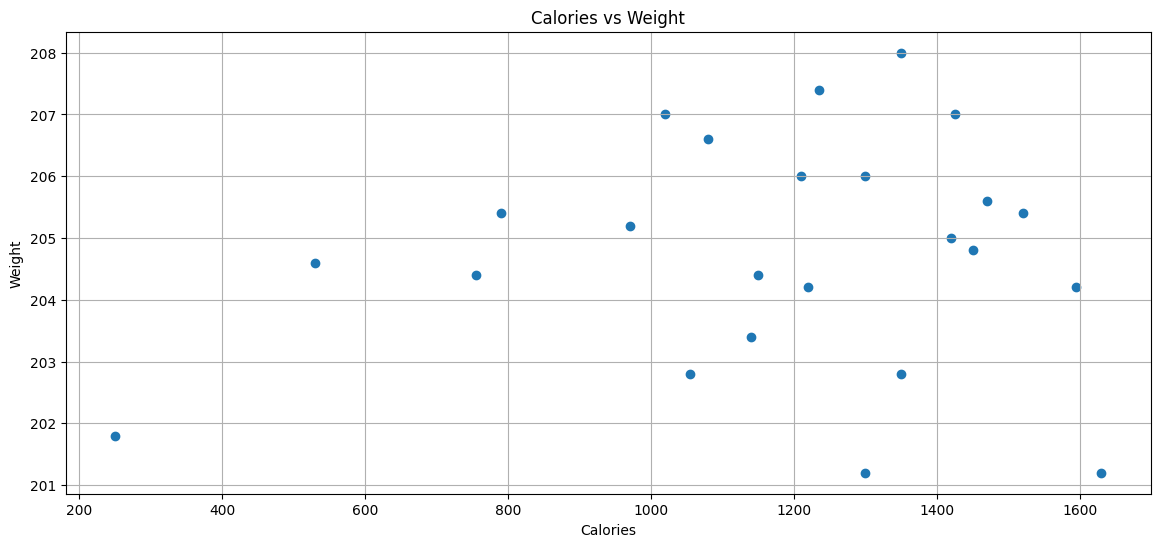

In [13]:
plt.figure(figsize=(14,6))

plt.scatter(
    combined["calories"],
    combined["weight_value"]
)

plt.title(
    "Calories vs Weight"
)

plt.xlabel("Calories")
plt.ylabel("Weight")

plt.grid(True)

plt.show()

# Top 20 Highest Calorie Foods

In [14]:
top_calories = (
    food_df
    .groupby("food_name")
    .agg(
        calories=("calories","sum")
    )
    .sort_values(
        "calories",
        ascending=False
    )
)

top_calories.head(20)

,calories
food_name,
Jimmy Bar,6500
homemade grilled cheeseburger (no bun) and a side of 6 tortilla chips,1725
2 single-wrapped Nutty Buddy bars,1550
Large slice Costco pizza,1420
Slices of Casey's Pepperoni Pizza (Large pie cuts),1120
2 Regular Arby's Roast Beef Sandwiches,1100
1 Double Roast Beef Sandwich and 1 Regular (Medium) Chocolate Shake,1100
English muffin breakfast-for-dinner sandwich with sausage and cheese,980
"1/2 of a Restaurant Cheeseburger , 1/4 Plate of French Fries Strawberry Sundae",970


# Summary Cell

In [15]:
summary = f"""
Nutrition Summary

Average Daily Calories:
{daily_food['calories'].mean():.0f}

Average Daily Phosphorus:
{daily_food['phosphorus'].mean():.0f} mg

Meals Logged:
{len(food_df)}

Most Frequently Logged Food:
{
food_df['food_name']
.value_counts()
.index[0]
}
"""

print(summary)


Nutrition Summary

Average Daily Calories:
1198

Average Daily Phosphorus:
834 mg

Meals Logged:
101

Most Frequently Logged Food:
Jimmy Bar



# average phosphorus per serving

In [16]:
food_analysis = (
    food_df
    .groupby("food_name")
    .agg(
        avg_phosphorus=("phosphorus_mg","mean"),
        avg_calories=("calories","mean"),
        times_eaten=("food_name","count")
    )
)

food_analysis = food_analysis[
    food_analysis["avg_calories"] > 0
]

food_analysis["phosphorus_per_calorie"] = (
    food_analysis["avg_phosphorus"]
    / food_analysis["avg_calories"]
)

food_analysis.sort_values(
    "phosphorus_per_calorie",
    ascending=False
).head(20)

,avg_phosphorus,avg_calories,times_eaten,phosphorus_per_calorie
food_name,,,,
baked beans,260.0,150.0,1,1.733333
Pancakes with syrup,285.0,185.0,1,1.540541
Pancakes,270.0,185.0,1,1.459459
1 standard Turkey and Cheddar Lunchables cracker pack,355.0,260.0,1,1.365385
Scrambled Eggs,110.0,90.0,1,1.222222
"Turkey, Cheese, Ritz crakers (5)",295.0,260.0,2,1.134615
4 ounces of Tikka Masala chicken with a minimal teaspoon of white rice,255.0,235.0,1,1.085106
Pork steak,190.0,185.0,1,1.027027
Large Slices of Bacon,120.0,120.0,1,1.000000


In [17]:
# Daily Nutrition Target Dashboard

MAX_SODIUM_MG = 2000
MAX_PHOSPHORUS_MG = 1000
MAX_CALORIES = 2200

latest_day = daily_food.iloc[-1]

calories_used = latest_day["calories"]
phosphorus_used = latest_day["phosphorus"]

print("Daily Nutrition Targets")
print("-" * 40)

print(
    f"Calories: "
    f"{calories_used:.0f} / {MAX_CALORIES:,}"
)

print(
    f"Remaining Calories: "
    f"{MAX_CALORIES - calories_used:.0f}"
)

print()

print(
    f"Phosphorus: "
    f"{phosphorus_used:.0f} / {MAX_PHOSPHORUS_MG:,} mg"
)

print(
    f"Remaining Phosphorus: "
    f"{MAX_PHOSPHORUS_MG - phosphorus_used:.0f} mg"
)

Daily Nutrition Targets
----------------------------------------
Calories: 250 / 2,200
Remaining Calories: 1950

Phosphorus: 182 / 1,000 mg
Remaining Phosphorus: 818 mg
